In [1]:
import enerhabitat as eh
import pandas as pd
import matplotlib.pyplot as plt
from iertools.read import read_sql

In [2]:
def evaluar(material, espesor, f):
    muro = eh.System(eh.Location(epw_file))
    muro.azimuth = 90
    muro.absortance = 0.3
    muro.layers = [(material,espesor)]
    muro.location.meanDay(month=5, year=2025)
    muro.Tsa()
    
    # solve devuelve solo un DataFrame
    data = muro.solveAC() #  data, et  = muro.solve(energy=True) ## mod MM
    data = pd.concat([data, muro.Tsa().asfreq('10min')], axis=1)
    data.index = data.index.tz_localize(None)
    muro.info()
    
    adobe = read_sql(f, alias=True).data
    
    fig, ax = plt.subplots(2,1,figsize=(12,4))

    # ax[0].plot(data.Tsa,label='Tsa')
    ax[0].plot(data.Ti, label='Ti_EH')
    ax[0].plot(adobe.Ti_CUBO, label='Ti_E+')
    ax[0].legend()
    
    ax[1].plot(data.Is, label='Is')
    ax[1].plot(data.Ig, label='Ig')
    ax[1].legend()

In [3]:
eh.config.file = "materials.ini"
epw_file = "../epw/Temixco_2018CST.epw"

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Energy transfer: None
Cooling energy: 770369.2557948494
Heating energy: 193625.58606128235
Layers:
	1: Adobe, 0.1 m


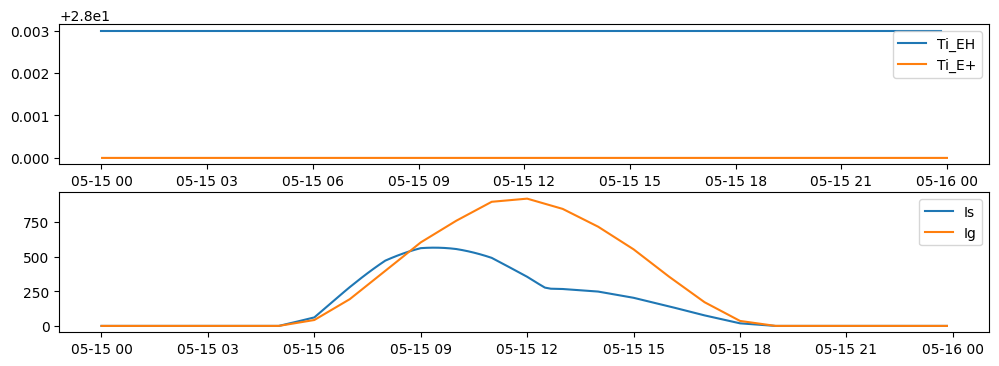

In [4]:
material = 'Adobe'
espesor = 0.1
f = '../idf/10cmAdobe_AC.sql'

evaluar(material,espesor,f)

In [5]:
eh.config.file = "materials.ini"
epw_file = "../epw/Temixco_2018CST.epw"


muro = eh.System(eh.Location(epw_file))
muro.azimuth = 90
muro.absortance = 0.3
muro.layers = [('Adobe',0.10)]
muro.location.meanDay(month=5, year=2025)
muro.Tsa()

,zenith,elevation,azimuth,equation_of_time,Ta,Ig,Ib,Id,Tn,DeltaTn,Is,Tsa
2025-05-15 00:00:00-06:00,141.364294,-51.364294,347.484908,3.667473,25.451540,0.003672,0.058140,0.0,28.002998,1.5,0.000459,25.451550
2025-05-15 00:00:01-06:00,141.365145,-51.365145,347.491071,3.667473,25.451143,0.003673,0.058133,0.0,28.002998,1.5,0.000459,25.451154
2025-05-15 00:00:02-06:00,141.365996,-51.365996,347.497235,3.667473,25.450747,0.003673,0.058127,0.0,28.002998,1.5,0.000459,25.450758
2025-05-15 00:00:03-06:00,141.366847,-51.366847,347.503398,3.667473,25.450351,0.003674,0.058120,0.0,28.002998,1.5,0.000459,25.450361
2025-05-15 00:00:04-06:00,141.367698,-51.367698,347.509562,3.667473,25.449954,0.003675,0.058113,0.0,28.002998,1.5,0.000459,25.449965
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-15 23:58:56-06:00,141.082048,-51.082048,347.167244,3.650390,25.476922,0.019102,0.065253,0.0,28.002998,1.5,0.002388,25.476977
2025-05-15 23:58:57-06:00,141.082921,-51.082921,347.173353,3.650390,25.476525,0.019102,0.065253,0.0,28.002998,1.5,0.002388,25.476581
2025-05-15 23:58:58-06:00,141.083793,-51.083793,347.179462,3.650390,25.476129,0.019102,0.065253,0.0,28.002998,1.5,0.002388,25.476184
2025-05-15 23:58:59-06:00,141.084665,-51.084665,347.185571,3.650389,25.475732,0.019102,0.065253,0.0,28.002998,1.5,0.002388,25.475787


In [6]:
muro.solveAC()

2025-05-15 00:00:00-06:00    28.002998
2025-05-15 00:10:00-06:00    28.002998
2025-05-15 00:20:00-06:00    28.002998
2025-05-15 00:30:00-06:00    28.002998
2025-05-15 00:40:00-06:00    28.002998
                               ...    
2025-05-15 23:10:00-06:00    28.002998
2025-05-15 23:20:00-06:00    28.002998
2025-05-15 23:30:00-06:00    28.002998
2025-05-15 23:40:00-06:00    28.002998
2025-05-15 23:50:00-06:00    28.002998
Freq: 600s, Name: Ti, Length: 144, dtype: float64

In [7]:
muro.cooling_energy,muro.heating_energy

(np.float64(770369.2557948494), np.float64(193625.58606128235))

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Energy transfer: None
Cooling energy: 919015.4720393321
Heating energy: 291697.9483924647
Layers:
	1: Ladrillo, 0.1 m


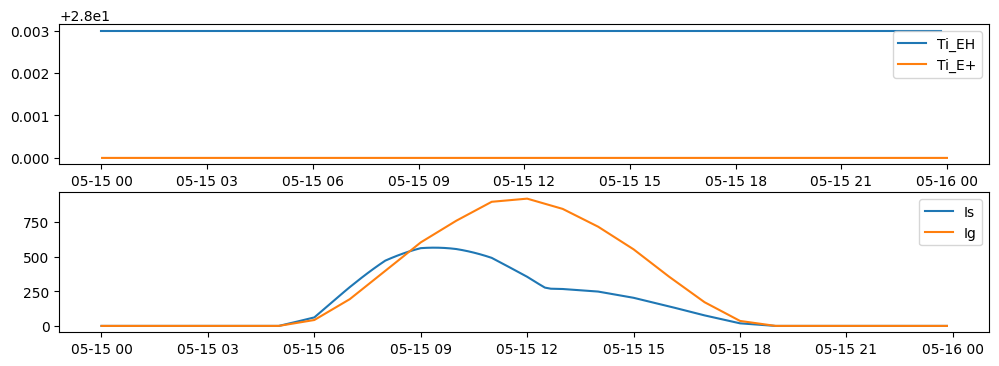

In [8]:
material = 'Ladrillo'
espesor = 0.1
f = '../idf/10cmLadrillo_AC.sql'

evaluar(material,espesor,f)

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Energy transfer: None
Cooling energy: 1154495.8049811
Heating energy: 366324.4091524936
Layers:
	1: Concreto, 0.1 m


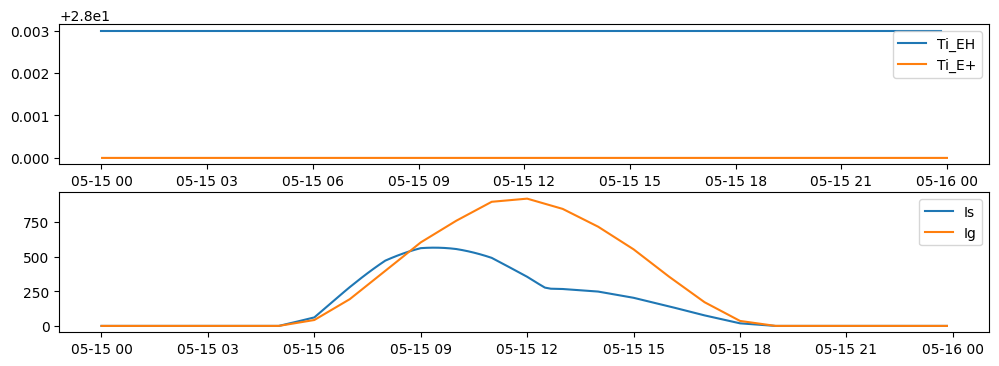

In [9]:
material = 'Concreto'
espesor = 0.1
f = '../idf/10cmConcreto_AC.sql'

evaluar(material,espesor,f)

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Energy transfer: None
Cooling energy: 116426.87022008702
Heating energy: 47136.49402580564
Layers:
	1: EPS, 0.1 m


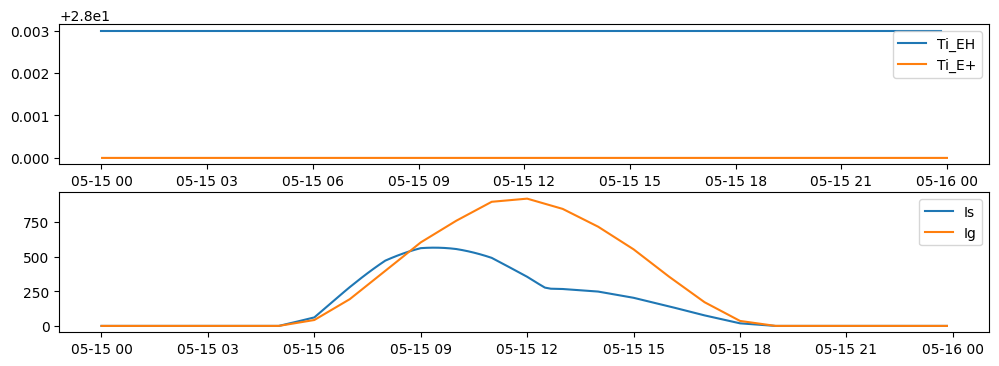

In [10]:
material = 'EPS'
espesor = 0.1
f = '../idf/10cmEPS_AC.sql'

evaluar(material,espesor,f)

<class 'enerhabitat.System'>
Location: Temixco, Morelos
meanDay date: 15-5-2025
Tilt: 90°
Azimuth: 90°
Absortance: 0.3
Energy transfer: None
Cooling energy: 1176657.5976279688
Heating energy: 336476.32660136383
Layers:
	1: CAD, 0.1 m


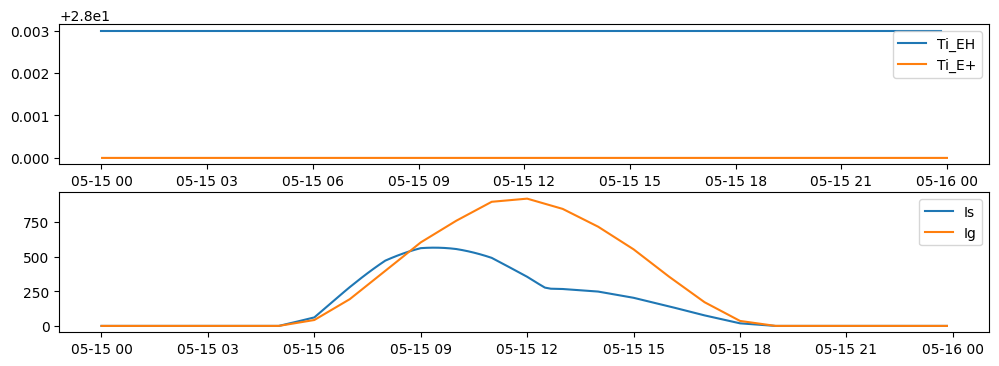

In [11]:
material = 'CAD'
espesor = 0.1
f = '../idf/10cmCAD_AC.sql'

evaluar(material,espesor,f)